courbe taux chomage moyen en france

In [4]:
import pandas as pd
import plotly.express as px

# Charger les données
df = pd.read_csv("valeurs_trimestrielles_sans_codes.csv", sep=';', encoding='utf-8')

# Garder seulement les colonnes de trimestres à partir de 2005
trimestres = [col for col in df.columns if "-T" in col and int(col[:4]) >= 2005]

# Moyenne nationale par trimestre
moyennes = df[trimestres].mean()

# Créer le DataFrame pour la courbe
courbe_df = pd.DataFrame({
    "Trimestre": moyennes.index,
    "Taux de chômage moyen (%)": moyennes.values
})

# Tracer la courbe
fig = px.line(
    courbe_df,
    x="Trimestre",
    y="Taux de chômage moyen (%)",
    title="Évolution du taux de chômage moyen en France (depuis 2005)",
    markers=True
)

fig.update_layout(
    xaxis_title="Trimestre",
    yaxis_title="Taux de chômage (%)",
    yaxis=dict(tickformat=".1f"),
    template="plotly_white"
)


fig.show()


départements avec la plus grande hausse du taux de chomage du au confinement

In [10]:
import pandas as pd
import numpy as np

# Charger les données
df = pd.read_csv("valeurs_trimestrielles_sans_codes.csv", sep=';')

# Extraire le nom propre du département
col_nom_dep = df.columns[0]
df[col_nom_dep] = df[col_nom_dep].str.extract(r'-\s*(.*)')

# Vérifier que les colonnes existent
if "2020-T2" not in df.columns or "2020-T3" not in df.columns:
    raise ValueError("Les colonnes 2020-T2 et/ou 2020-T3 sont absentes du fichier.")

# Calcul des écarts
df["Écart T3 - T2"] = np.abs(pd.to_numeric(df["2020-T3"], errors='coerce') - pd.to_numeric(df["2020-T2"], errors='coerce'))

# Trier par écart décroissant
df_sorted = df[[col_nom_dep, "2020-T2", "2020-T3", "Écart T3 - T2"]].sort_values(by="Écart T3 - T2", ascending=False)

# Affichage des 10 premiers
print("Top 10 des départements avec la plus forte variation du chômage entre 2020-T2 et 2020-T3 :")
print(df_sorted.head(10).to_string(index=False))


Top 10 des départements avec la plus forte variation du chômage entre 2020-T2 et 2020-T3 :
              Libellé  2020-T2  2020-T3  Écart T3 - T2
  Pyrénées-Orientales     11.1     14.0            2.9
    Seine-Saint-Denis      9.2     11.9            2.7
                Aisne      9.6     12.1            2.5
                 Aude      9.5     11.9            2.4
               Ariège      8.6     10.9            2.3
             Vaucluse      9.2     11.4            2.2
Territoire de Belfort      8.2     10.4            2.2
           Val-d'Oise      7.3      9.5            2.2
                 Nord      8.8     11.0            2.2
              Hérault     10.0     12.2            2.2


Courbe des 4 départements les + impactés par rapport a la moyenne nationale

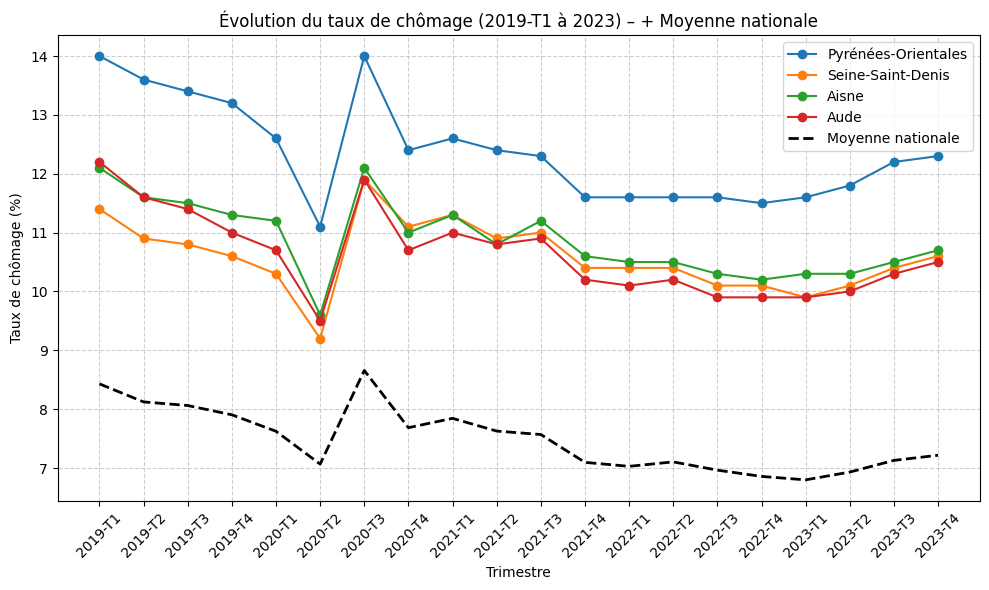

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Charger le CSV
df = pd.read_csv("valeurs_trimestrielles_sans_codes.csv", sep=';')

# Extraire le nom du département
col_nom_dep = df.columns[0]
df[col_nom_dep] = df[col_nom_dep].str.extract(r'-\s*(.*)')

# Liste des départements ciblés
departements_covid = ['Pyrénées-Orientales', 'Seine-Saint-Denis', 'Aisne', 'Aude']

# Colonnes de 2019-T1 à 2023-T4 (ajustées en fonction du fichier réel)
colonnes_cibles = [f"{annee}-T{trim}" for annee in range(2019, 2024) for trim in range(1, 5)]
colonnes_cibles = [col for col in colonnes_cibles if col in df.columns]

# Préparer le graphe
plt.figure(figsize=(10, 6))

# Tracer les courbes des départements sélectionnés
for dep in departements_covid:
    ligne_dep = df[df[col_nom_dep] == dep]
    if not ligne_dep.empty:
        valeurs = pd.to_numeric(ligne_dep[colonnes_cibles].values.flatten(), errors='coerce')
        plt.plot(colonnes_cibles, valeurs, marker='o', label=dep)


# Ajouter la courbe de moyenne nationale (moyenne de tous les départements)
moyennes_nationales = df[colonnes_cibles].apply(pd.to_numeric, errors='coerce').mean(axis=0)
plt.plot(colonnes_cibles, moyennes_nationales, color='black', linestyle='--', linewidth=2, label='Moyenne nationale')


# Personnalisation du graphique
plt.title("Évolution du taux de chômage (2019-T1 à 2023) – + Moyenne nationale")
plt.xlabel("Trimestre")
plt.ylabel("Taux de chômage (%)")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()
